## AB 테스트를 위한 간단한 템플릿 프로젝트

- 아래 내용을 참고해서 구현되었습니다
    - https://doubly8f.netlify.app/%EA%B0%9C%EB%B0%9C/2020/08/11/ab-test-all/
    - 결과 비교 화면 설계 (CI 기반 차트 설계) : https://brunch.co.kr/@herbeauty/54
    - 사용시 유의할 점 : https://namofvietnam.medium.com/before-after-a-b-testing-statistics-for-marketing-analytics-with-both-r-and-python-25eed4453e2
    - 어떻게 응용할까? : https://joshua-data.medium.com/harnessing-the-power-of-bigquery-and-python-overcoming-google-optimize-a-b-testing-limitations-9233365a0707

- 카이제곱 동질성 검정? 당근마켓 케이스
    - 평균에서 30배수 이상 값은 이상값으로 판단 (당근마켓에서는 평균으로부터 표준편차의 30배 이상 떨어지면 outlier라고 보고 값 제외 실시)
    - 비교 기준은 count 지표와 value_sum

In [ ]:
import os
import sys
import polars as pl
from pathlib import Path

# examples 폴더에서 실행 중인 경우에만 부모로 이동
current_dir = Path.cwd()
if current_dir.name == 'examples':
    project_root = current_dir.parent
else:
    project_root = current_dir

# Python 경로에 추가 및 작업 디렉토리 변경
sys.path.insert(0, str(project_root))
os.chdir(project_root)

from packages.ABTest.BinaryTest import two_group_proportion_test_from_data, two_group_proportion_test_from_summary
from packages.ABTest.NumericalTest import two_group_numerical_test_from_data
from packages.ABTest.postABTest import binary_sample_size_calc

print(f"현재 작업 디렉토리: {os.getcwd()}")

현재 작업 디렉토리: d:\Github\DataAnalyticsTools\DataAnalyticsTools


### 기본 데이터 불러오기


In [3]:
DATA_PATH_LOGIT = './shared/ab_test_example_data/logistic_dataset.csv'
DATA_PATH_NORM = './shared/ab_test_example_data/normal_dataset.csv'
DATA_PATH_GAMMA = './shared/ab_test_example_data/gamma_dataset.csv'

### 범주형 데이터 (비율 데이터 -> 클릭, 전환 등)의 A/B 테스트

- 두 집단에 대한 A/B 테스트를 수행합니다
- 양측 검정, 단측 검정 중 하나를 수행할 수 있습니다
- 단측 검정의 경우, smaller / larger를 설정해야만 합니다

### 데이터의 표본을 구하기 위해 다음과 같은 방법을 사용할 수 있습니다
- 범주형 데이터의 표본 수를 구하기 위해서는 다음 함수를 사용합니다
- diff (최소 차이 효과), 2번 집단의 비율, 검정력, 유의수준, 검정 방법을 사전에 알고 정의해야합니다

### 이 범주형 테스트는 두 종류의 테스트를 수행합니다
- Z-test (비율 데이터)에 대한 검정 방법 (일반적으로 수행)
- Fisher's Exact Test (피셔 정확 검정) (Z-test를 위한 조건 미 충족시 수행)
- 범주가 logistic인 경우에만 사용하는것이 올바른 함수입니다. A, B, C 등 세개 이상이 분포가 같나? 를 검정하기 위해서는 카이제곱 검정이 필요

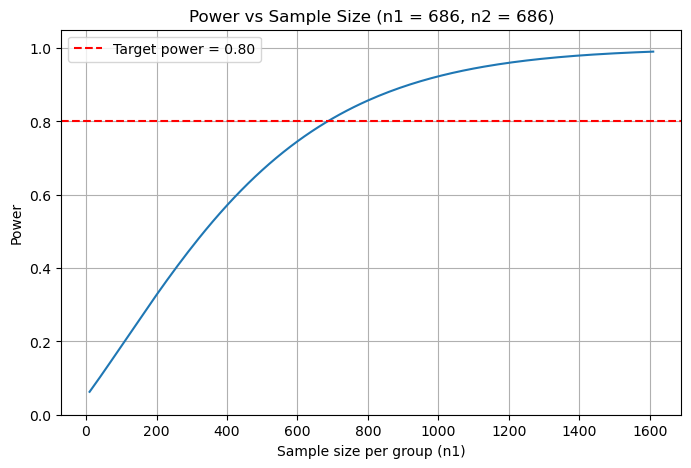

{'group1': 685.596858325361, 'group2': 685.596858325361}

In [4]:
binary_sample_size_calc(diff=0.05, prop2=0.1, power=0.8, ratio=1, alpha=0.05, alternative='two-sided', plot_curve=True)

### 데이터는 가공된 데이터의 원본 형태 또는 숫자형 데이터가 존재해야합니다
- two_group_proportion_test_from_data를 사용하기 위한 데이터의 형태는 아래와 같습니다
- two_group_proportion_test_from_summary를 사용하기 위해서는 na, nb, xa, xb가 필요합니다

In [5]:
data = pl.read_csv(DATA_PATH_LOGIT)
data.head(2)

group,is_purchase
str,i64
"""B""",1
"""B""",0



          Two-Proportion Z-Test가 수행되었습니다
            ------------------------------------------------
            이표본 양측 비율 검정 결과
            ------------------------------------------------
            유의수준 α = 0.05   신뢰수준 = 95.0%

            그룹 A: A (n=700, x=302, p=0.4314 95.0% CI: 0.3947 ~ 0.4681)
            그룹 B: B (n=800, x=270, p=0.3375 95.0% CI: 0.3047 ~ 0.3703)
            * 신뢰구간은 Wald score interval 방법으로 계산 되었습니다
            ------------------------------------------------
            H0: p(A) = p(B)
            H1: p(A) ≠ p(B)
            diff : 0.0939 (95.0% CI: 0.0447 ~ 0.1431) | p-value = 0.00019
            결론: 귀무가설 기각
            ------------------------------------------------
          


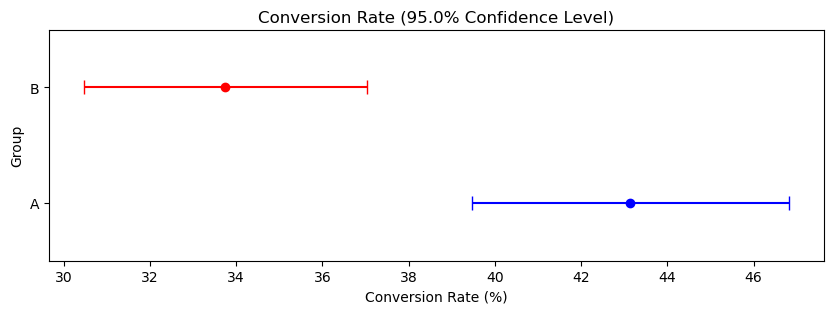

{'z': 3.7365031926316647,
 'p_value': 0.00018659708095000168,
 'label_a': 'A',
 'pa': 0.43142857142857144,
 'label_b': 'B',
 'pb': 0.3375,
 'ci_a': (0.3947387127868551, 0.4681184300702878),
 'ci_b': (0.3047332832131907, 0.37026671678680934)}

In [6]:
two_group_proportion_test_from_data(data,
                                    group_col='group',
                                    target_col='is_purchase',
                                    alpha=0.05,
                                    alternative='two-sided')


          Two-Proportion Z-Test가 수행되었습니다
            ------------------------------------------------
            이표본 양측 비율 검정 결과
            ------------------------------------------------
            유의수준 α = 0.05   신뢰수준 = 95.0%

            그룹 A: A (n=1000, x=200, p=0.2000 95.0% CI: 0.1752 ~ 0.2248)
            그룹 B: B (n=1000, x=180, p=0.1800 95.0% CI: 0.1562 ~ 0.2038)
            * 신뢰구간은 Wald score interval 방법으로 계산 되었습니다
            ------------------------------------------------
            H0: p(A) = p(B)
            H1: p(A) ≠ p(B)
            diff : 0.0200 (95.0% CI: -0.0144 ~ 0.0544) | p-value = 0.25430
            결론: 귀무가설 기각 실패
            ------------------------------------------------
          


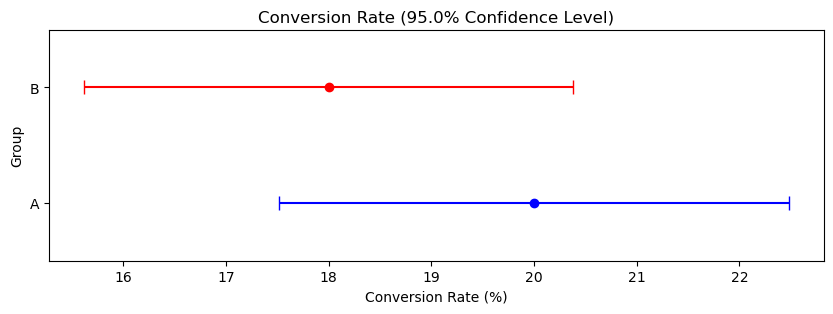

{'z': 1.1399759467612833,
 'p_value': 0.2542963222169887,
 'label_a': 'A',
 'pa': 0.2,
 'label_b': 'B',
 'pb': 0.18,
 'ci_a': (0.17520819870781754, 0.22479180129218249),
 'ci_b': (0.1561882524384611, 0.2038117475615389)}

In [7]:
two_group_proportion_test_from_summary(xa=200, xb=180, na=1000, nb=1000,
                                       alpha=0.05,
                                       alternative='two-sided')

### 수치형 (연속형) 데이터의 A/B 테스트

- 두 집단에 대한 A/B 테스트를 수행합니다
- 양측 검정, 단측 검정 중 하나를 수행할 수 있습니다
- 단측 검정의 경우, smaller / larger를 설정해야만 합니다

In [8]:
data = pl.read_csv(DATA_PATH_NORM)
data.head(2)

group,purchase
str,f64
"""B""",92.504333
"""B""",93.00482
